In [3]:
import numpy as np
import pandas as pd

# Thiết lập seed để kết quả ngẫu nhiên có thể tái lập
np.random.seed(42)

# Số lượng mẫu
n_samples = 100

# Tạo 2 biến độc lập (x1, x2)
x1 = np.random.uniform(0, 10, n_samples)  # Giá trị ngẫu nhiên từ 0 đến 10
x2 = np.random.uniform(0, 20, n_samples)  # Giá trị ngẫu nhiên từ 0 đến 20

# Hệ số hồi quy thực sự (beta1, beta2) và hằng số (intercept)
beta1 = 2.5
beta2 = -1.2
intercept = 5

# Tạo biến mục tiêu (y) dựa trên mô hình tuyến tính cộng thêm nhiễu ngẫu nhiên
noise = np.random.normal(0, 2, n_samples)  # Nhiễu với phân phối chuẩn (mean=0, std=2)
y = intercept + beta1 * x1 + beta2 * x2 + noise

# Tạo DataFrame từ dữ liệu
data = pd.DataFrame({
    'x1': x1,
    'x2': x2,
    'y': y
})

In [5]:
data

,x1,x2,y
0,3.745401,0.628584,12.249153
1,9.507143,12.728208,13.958515
2,7.319939,6.287120,16.341450
3,5.986585,10.171414,6.332063
4,1.560186,18.151329,-9.149580
...,...,...,...
95,4.937956,6.984191,7.657202
96,5.227328,14.519114,4.176293
97,4.275410,17.942205,-5.032157
98,0.254191,17.741728,-18.176364


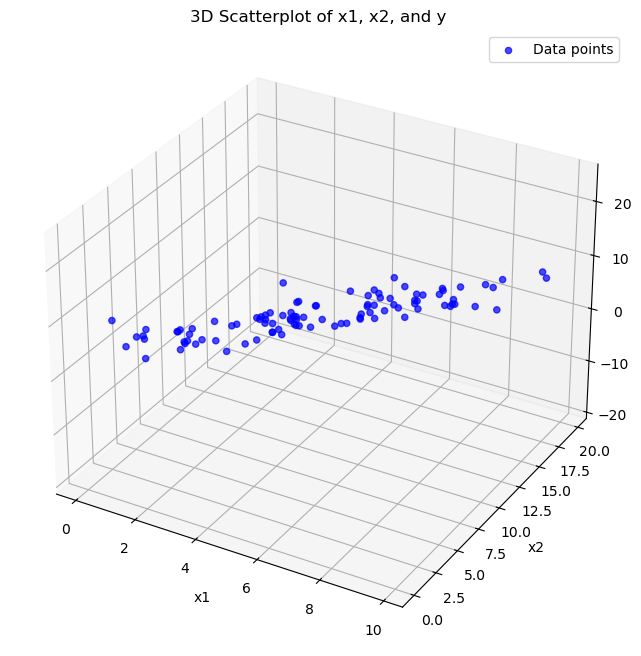

In [52]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Tạo figure và axis 3D
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Vẽ scatterplot 3D
ax.scatter(data['x1'], data['x2'], data['y'], c='blue', alpha=0.7, label='Data points')

# Gắn nhãn cho các trục
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('y')
ax.set_title('3D Scatterplot of x1, x2, and y')

# Hiển thị legend
ax.legend()

# Hiển thị biểu đồ
plt.show()


In [98]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge


model = LinearRegression(fit_intercept=True)
model.fit(data[['x1', 'x2']], data['y'])

LinearRegression()

In [100]:
coef = model.coef_
intercept = model.intercept_
print(coef, intercept)

[ 2.43165494 -1.12806886] 4.821220072900149


In [102]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np

def plot_3D(coef, intercept):
    # Thiết lập hệ số mặt phẳng: z = ax + by
    a = coef[0]  # Hệ số của x
    b = coef[1]  # Hệ số của y
    intercept = 5  # Hằng số c
    
    # Tạo một lưới điểm x, y trong không gian 3D
    x = np.linspace(0, 10, 100)  # Giá trị x trong khoảng [0, 10]
    y = np.linspace(0, 20, 100)  # Giá trị y trong khoảng [0, 20]
    x, y = np.meshgrid(x, y)  # Tạo lưới điểm (x, y)
    
    # Tính z từ phương trình z = ax + by + intercept
    z = a * x + b * y + intercept
    
    # Tạo figure và axis 3D
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # Vẽ mặt phẳng
    ax.plot_surface(x, y, z, alpha=0.5, rstride=100, cstride=100, cmap='viridis', edgecolor='none')
    
    # Vẽ scatterplot của dữ liệu
    ax.scatter(data['x1'], data['x2'], data['y'], color='red', label='Data points')
    
    # Gắn nhãn cho các trục
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_zlabel('y')
    ax.set_title('3D Scatterplot with Regression Plane')
    
    # Hiển thị legend
    ax.legend()
    
    # Hiển thị biểu đồ
    plt.show()


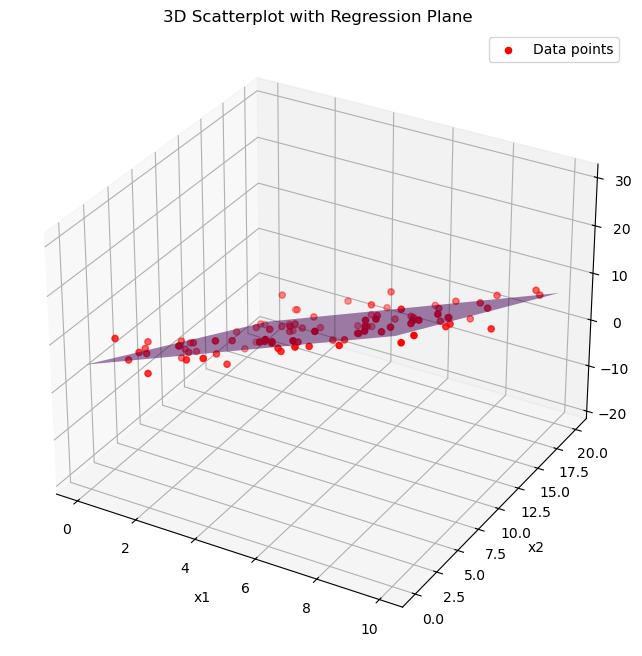

In [104]:
plot_3D(coef, intercept)

Text(0.5, 1.0, 'Relationship between x1 and y')

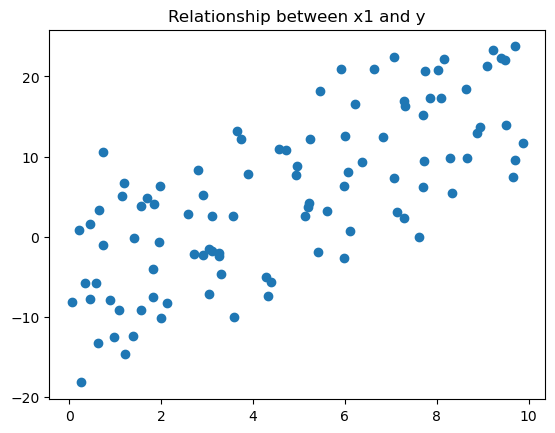

In [90]:
plt.scatter(data['x1'], data['y'])
plt.title('Relationship between x1 and y')

In [106]:
model = Ridge()
model.fit(data[['x1', 'x2']], data['y'])

Ridge()

In [108]:
coef = model.coef_
intercept = model.intercept_
print(coef, intercept)

[ 2.42890173 -1.12778492] 4.831338043645293


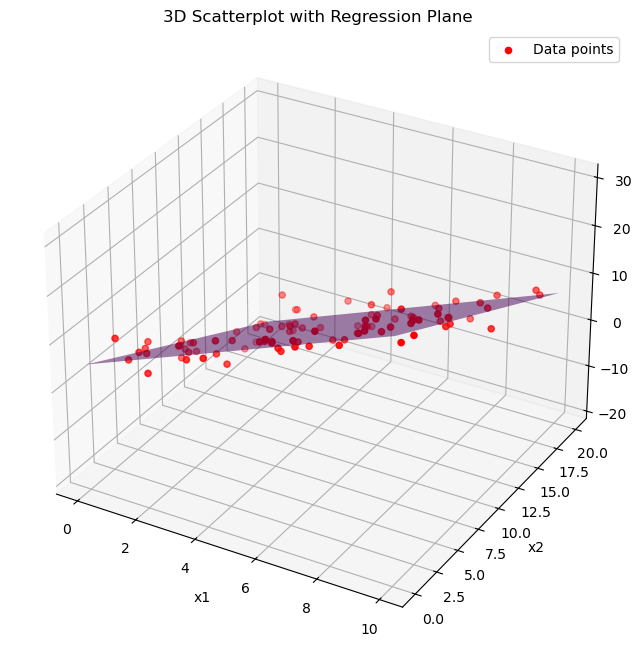

In [110]:
plot_3D(coef, intercept)

In [112]:
model = Lasso()
model.fit(data[['x1', 'x2']], data['y'])

Lasso()

In [114]:
coef = model.coef_
intercept = model.intercept_
print(coef, intercept)

[ 2.31936037 -1.10061551] 5.075864511630717


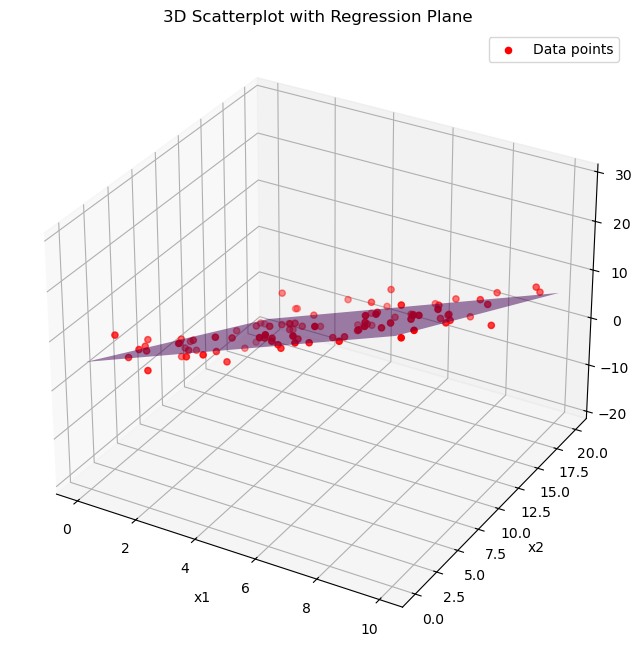

In [116]:
plot_3D(coef, intercept)